# Exploratory data analysis (EDA) of car data

## Libraries and settings

In [2]:
# Libraries
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, timedelta

# seaborn graphics settings
sns.set_theme(color_codes=True)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Show current working directory
print(os.getcwd())

/workspaces/python_exploratory_data_analysis


## Importing the car data

### Importing the car data

In [3]:
# Columns to read
columns = ["Offer_Id",
            "Type",
            "Price",
            "HP",
            "Mileage",
            "Fuel_Type",
            "Transmission",
            "Dealer_PLZ",
            "Dealer_City",
            "Dealer_Street_House_Nr",
            "Init_Regist_MY",
            "Init_Regist_Month",
            "Init_Regist_Year",
            "Init_Regist_Dt"]

# Read and select variables
df_orig = pd.read_csv("autoscout24_data_enriched_cleaned.csv", sep=",")[columns]

# Change column names to lower case
df_orig.columns = df_orig.columns.str.lower()

# Remove duplicates
df_orig = df_orig.drop_duplicates()
df_orig.head(5)

# Remove missing values
df = df_orig.dropna()
df.head(5)

,offer_id,type,price,hp,mileage,fuel_type,transmission,dealer_plz,dealer_city,dealer_street_house_nr,init_regist_my,init_regist_month,init_regist_year,init_regist_dt
0,7324420,AUDI A5 Sportback 3.0 TDI quattro S-tronic (Li...,22500,245,75000,Diesel,Automatisiertes Schaltgetriebe,8488,Turbenthal,Mettlenstrasse 3,10.2014,10.0,2014.0,2014-10
1,7512768,MERCEDES-BENZ SLK 200 7G-Tronic (Cabriolet),23749,184,46655,Benzin,Automat sequentiell,3186,Düdingen,Brugerastrasse 60,6.2013,6.0,2013.0,2013-06
2,7512034,MERCEDES-BENZ C 350 Avantgarde 4Matic 7G-Troni...,18500,306,138955,Benzin,Automat sequentiell,1262,Eysins,1262 Eysins,6.2011,6.0,2011.0,2011-06
3,7512728,MERCEDES-BENZ A 45 AMG 4Matic Speedshift 7G-DC...,36000,360,43000,Benzin,Automatisiertes Schaltgetriebe,4314,Zeiningen,Am Stutz 21,8.2015,8.0,2015.0,2015-08
4,7490242,AUDI A5 Sportback 2.0 TFSI Sport quattro S-tro...,48500,252,43300,Benzin,Automatisiertes Schaltgetriebe,3250,Lyss,3250 Lyss,9.2018,9.0,2018.0,2018-09


## Univariate non-graphical exploratory data analysis (EDA)

### Quantiles

In [4]:
# Calculate Quantiles 
df[['price', 'hp', 'mileage']].quantile(
    q=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).round(2)

,price,hp,mileage
0.05,4000.0,90.0,13700.0
0.10,5900.0,110.0,23000.0
0.25,10900.0,150.0,45000.0
0.50,19900.0,204.0,83500.0
0.75,35900.0,306.0,130000.0
0.90,56900.0,405.0,176000.0
0.95,72500.0,469.5,206090.5


### Shape (number of rows and colums)

In [5]:
# Number of rows and columns
print (df.shape)

(3971, 14)


### Data types

In [6]:
# Show data types
df.dtypes

offer_id                    int64
type                       object
price                       int64
hp                          int64
mileage                     int64
fuel_type                  object
transmission               object
dealer_plz                  int64
dealer_city                object
dealer_street_house_nr     object
init_regist_my            float64
init_regist_month         float64
init_regist_year          float64
init_regist_dt             object
dtype: object

### Summary statistics of numeric variables

In [7]:
# Show summary statistics of variables
df.describe()

,offer_id,price,hp,mileage,dealer_plz,init_regist_my,init_regist_month,init_regist_year
count,3.971000e+03,3971.000000,3971.000000,3971.000000,3971.000000,3971.000000,3971.000000,3971.000000
mean,7.242907e+06,27527.641652,235.831025,92952.412491,5522.633594,6.510513,6.309494,2010.189121
std,4.655890e+05,26670.221155,119.671388,61097.990134,2848.337824,3.386338,3.386320,9.610067
min,1.395491e+06,160.000000,16.000000,1.000000,1000.000000,1.194600,1.000000,1929.000000
25%,7.249691e+06,10900.000000,150.000000,45000.000000,3014.000000,3.201800,3.000000,2008.000000
50%,7.408668e+06,19900.000000,204.000000,83500.000000,6003.000000,6.201400,6.000000,2013.000000
75%,7.456806e+06,35900.000000,306.000000,130000.000000,8304.500000,9.201500,9.000000,2016.000000
max,7.512843e+06,428000.000000,772.000000,370000.000000,9657.000000,12.201900,12.000000,2020.000000


### Statistical measures (min, max, std, mean, median, count) for selected variables

In [8]:
# Price
print('price:',
      'count:', round(df['price'].count(), 1),      #diesr Code definiert die Ausgabe der Statistik für die Spalte 'price'
      'min:', round(df['price'].min(), 1),          #dieser Code definiert die minimale Ausgabe der Statistik für die Spalte 'price'
      'max:', round(df['price'].max(), 1),          #dieser Code definiert die maximale Ausgabe der Statistik für die Spalte 'price'
      'mean:', round(df['price'].mean(), 1),        #dieser Code definiert die durchschnittliche Ausgabe der Statistik für die Spalte 'price'
      'median:', round(df['price'].median(), 1),    #dieser Code definiert die mittlere Ausgabe der Statistik für die Spalte 'price'
      'std:', round(df['price'].std(), 1))          #dieser Code definiert die Standardabweichung der Ausgabe der Statistik für die Spalte 'price'

# Area
print('area:',
      'count:', round(df.mileage.count(), 1),      #diesr Code definiert die Ausgabe der Statistik für die Spalte 'mileage'
      'min:', round(df.mileage.min(), 1),          #dieser Code definiert die minimale Ausgabe der Statistik für die Spalte 'mileage'
      'max:', round(df.mileage.max(), 1),          #dieser Code definiert die maximale Ausgabe der Statistik für die Spalte 'mileage'
      'mean:', round(df.mileage.mean(), 1),       #dieser Code definiert die durchschnittliche Ausgabe der Statistik für die Spalte 'mileage'
      'median:', round(df.mileage.median(), 1),   #dieser Code  definiert die mittlere Ausgabe der Statistik für die Spalte 'mileage'
      'std:', round(df.mileage.std(), 1))         #dieser Code definiert die Standardabweichung der Ausgabe der Statistik für die Spalte 'mileage'



price: count: 3971 min: 160 max: 428000 mean: 27527.6 median: 19900.0 std: 26670.2
area: count: 3971 min: 1 max: 370000 mean: 92952.4 median: 83500.0 std: 61098.0


### Skewness

In [9]:
# Show skewness of selected variables
df[['price', 'hp', 'mileage']].skew()

#die Skewness bezeichnet die Asymmetrie einer Wahrscheinlichkeitsverteilung um ihren Mittelwert.

price      4.077049
hp         1.093046
mileage    0.886538
dtype: float64

### Kurtosis

In [10]:
# Show kurtosis of selected variables
df[['price', 'hp', 'mileage']].kurtosis()

#die Kurtosis beschreibt die Wölbung einer Wahrscheinlichkeitsverteilung im Vergleich zu einer Normalverteilung.

price      36.506763
hp          1.226153
mileage     0.739533
dtype: float64

### Extreme values

In [11]:
# Low costs cars
df[df['price'] <=500]

#mit dieser Funktion werden alle Autos mit einem Preis von weniger als oder gleich 500 angezeigt

,offer_id,type,price,hp,mileage,fuel_type,transmission,dealer_plz,dealer_city,dealer_street_house_nr,init_regist_my,init_regist_month,init_regist_year,init_regist_dt
1651,7452246,FIAT Punto 1.4 16V Sporting (Kleinwagen),500,95,127600,Benzin,Schaltgetriebe manuell,2000,Neuchâtel,Rue Léon-Berthoud 14,7.2004,7.0,2004.0,2004-07
3704,7372156,VW Golf Variant 1800 Rolling Stones (Kombi),160,90,217650,Benzin,Schaltgetriebe manuell,1426,Concise,Aux Petits Prés 1,10.1995,10.0,1995.0,1995-10
3905,7510439,VOLVO V70 2.5 T XC AWD Nordic (Kombi),400,193,253000,Benzin,Automat,9553,Bettwiesen,Hauptstrasse 51,1.1999,1.0,1999.0,1999-01


In [12]:
# Very expansive cars
df[df['price'] >=250000]

#mit dieser Funktion werden alle Autos mit einem Preis von mehr als oder gleich 250000 angezeigt

,offer_id,type,price,hp,mileage,fuel_type,transmission,dealer_plz,dealer_city,dealer_street_house_nr,init_regist_my,init_regist_month,init_regist_year,init_regist_dt
312,6978696,LAMBORGHINI Aventador S LP740-4 Roadster E-Gea...,384900,741,4000,Benzin,Automatisiertes Schaltgetriebe,8008,Zürich,8008 Zürich,6.2018,6.0,2018.0,2018-06
1621,6395032,PORSCHE 911 GT2 RS (Coupé),428000,620,8900,Benzin,Schaltgetriebe manuell,1628,Vuadens,Route principale 144,1.2011,1.0,2011.0,2011-01
1824,5887777,MERCEDES-BENZ 220 SE (Cabriolet),255000,120,1200,Benzin,Schaltgetriebe manuell,6052,Hergiswil,Sonnenbergstrasse 9,7.1960,7.0,1960.0,1960-07
2714,7448261,PORSCHE 911 Speedster Manual Gearbox Chalk whi...,379000,510,14,Benzin,Schaltgetriebe,1004,Lausanne,.,3.2020,3.0,2020.0,2020-03
3876,6768872,McLAREN 675LT Coupé 3.8 V8 SSG (Coupé),280000,675,11500,Benzin,Automatisiertes Schaltgetriebe,1202,Geneve,1202 Geneve,3.2016,3.0,2016.0,2016-03


### Get a list of categories of categorical variable

In [13]:
# Get a list of categories of the variable fuel_type
np.array(pd.Categorical(df['fuel_type']).categories)

#mit dieser Funktion werden alle Kategorien der Variablen 'fuel_type' angezeigt

array(['Automat', 'Automatik-Getriebe', 'Benzin', 'Diesel', 'Elektro',
       'Erdgas (CNG) / Benzin', 'Flüssiggas (LPG) / Benzin',
       'Hybrid Benzin/Elektro', 'Hybrid Diesel/Elektro',
       'Mild-Hybrid Benzin/Elektro', 'Mild-Hybrid Diesel/Elektro',
       'Plug-in-Hybrid Benzin/Elektro', 'Plug-in-Hybrid Diesel/Elektro',
       'Schaltgetriebe', 'Schaltgetriebe manuell',
       'Voll-Hybrid Benzin/Elektro', 'Voll-Hybrid Diesel/Elektro'],
      dtype=object)

## Multivariate non-graphical exploratory data analysis (EDA)

### Cross-tabulation

In [14]:
# Create a crosstab of the variables fuel_type and transmission
pd.crosstab(df['fuel_type'], df['transmission'])

#mit dieser Funktion wird eine Kreuztabelle der Variablen --> ein Crosstab ist eine tabellarische Darstellung der Häufigkeitsverteilung von Variablen

transmission,Allrad,Automat,Automat sequentiell,Automat stufenlos,"Automat stufenlos, sequentiell",Automatik-Getriebe,Automatisiertes Schaltgetriebe,Hinterradantrieb,Schaltgetriebe,Schaltgetriebe manuell,Schaltgetriebe sequentiell
fuel_type,,,,,,,,,,,
Automat,0,0,0,0,0,0,0,1,0,0,0
Automatik-Getriebe,1,0,0,0,0,0,0,0,0,0,0
Benzin,1,244,487,8,25,62,713,1,35,1070,2
Diesel,0,64,564,1,11,21,198,0,10,306,0
Elektro,0,0,0,6,0,1,58,0,0,2,0
Erdgas (CNG) / Benzin,0,0,0,0,0,0,0,0,0,1,0
Flüssiggas (LPG) / Benzin,0,0,0,0,0,0,0,0,0,1,0
Hybrid Benzin/Elektro,0,0,0,0,0,1,0,0,0,0,0
Hybrid Diesel/Elektro,0,0,0,0,0,0,0,0,1,0,0


### Pivot tables

In [15]:
# Using pivot_table with averages of price, mileage and hp of the cars by fuel type
pd.pivot_table(df[['mileage', 'price', 'hp', 'fuel_type']],     #definiert die DataFrame mit den ausgewählten Variablen
                  index = ['fuel_type'],                        #die Variable, nach der die Pivot-Tabelle gruppiert wird
                  values = ['price', 'mileage', 'hp'],          #die Variablen, für die die Pivot-Tabelle erstellt wird
                  aggfunc = (np.mean, 'count')).round(2)        #die Funktion np.mean berechnet den Durchschnittswert wobei aggfunc die Aggregationsfunktion angibt

hp         mileage            price          
                              count    mean   count       mean count      mean
fuel_type                                                                     
Automat                           1  304.00       1   76000.00     1  49000.00
Automatik-Getriebe                1  258.00       1   37800.00     1  79999.00
Benzin                         2648  247.91    2648   89429.19  2648  27889.74
Diesel                         1175  197.28    1175  104776.46  1175  24976.57
Elektro                          67  446.57      67   61678.73    67  51967.18
Erdgas (CNG) / Benzin             1   85.00       1   50561.00     1   5900.00
Flüssiggas (LPG) / Benzin         1   97.00       1   83000.00     1   4800.00
Hybrid Benzin/Elektro             1  339.00       1  128356.00     1  19900.00
Hybrid Diesel/Elektro             1  261.00       1  263209.00     1  34000.00
Mild-Hybrid Benzin/Elektro        3  269.67       3   19536.67     3  60130.00
Mild-Hybrid Diesel/Elektro        2  340.00       2   18295.00     2  82250.00
Plug-in-Hybrid Benzin/Elektro    26  278.69      26   44840.38    26  40159.62
Plug-in-Hybrid Diesel/Elektro     4  286.00       4   68871.75     4  28622.50
Schaltgetriebe                    3  242.67       3  107500.33     3  28383.33
Schaltgetriebe manuell            1  125.00       1   65000.00     1  31900.00
Voll-Hybrid Benzin/Elektro       31  168.48      31   67621.29    31  23470.65
Voll-Hybrid Diesel/Elektro        5  200.20       5   80300.00     5  17837.40

### Correlation matrix

In [16]:
# Calculate correlation matrix of the variables mileage, price and hp
corr = df[['mileage',           #dieser Code definiert die DataFrame mit den ausgewählten Variablen
            'price', 
            'hp',
            ]].corr()
corr                            #dieser Code zeigt die Korrelationsmatrix der Variablen 'mileage', 'price' und 'hp' an

#Die Korrelation ist hoch wenn der Wert nahe bei 1 liegt und schlecht wenn der Wert nahe bei 0 liegt / negative Werte zeigen eine negative Korrelation an (eine negative Korrelation bedeutet, dass wenn eine Variable steigt, die andere fällt)

,mileage,price,hp
mileage,1.000000,-0.436815,-0.126362
price,-0.436815,1.000000,0.614575
hp,-0.126362,0.614575,1.000000


### Covariance matrix

In [17]:
# Calculate covariance matrix of the variables mileage, price and hp
cov = df[['mileage',
            'price', 
            'hp',
            ]].cov()
cov                             #dieser Code zeigt die Kovarianzmatrix der Variablen 'mileage', 'price' und 'hp' an
                                #die Kovariantz ist ein Maß dafür, wie zwei Variablen gemeinsam variieren. Eine negative Kovarianz bedeutet, dass wenn eine Variable steigt, die andere fällt.

,mileage,price,hp
mileage,3.732964e+09,-7.117892e+08,-9.239156e+05
price,-7.117892e+08,7.113007e+08,1.961515e+06
hp,-9.239156e+05,1.961515e+06,1.432124e+04


## Univariate graphical exploratory data analysis (EDA)

### Line chart (matplotlib)

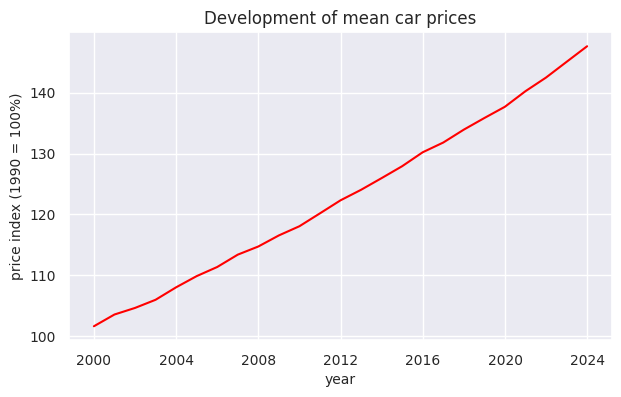

In [18]:
# Generate time series data for mean car prices over the last 20 years
x = []          #definiert die Liste x für die Zeitachse
y = []          #definiert die Liste y für die Preisachse


# Start from 25 years ago with an initial price
start_date_trend =datetime(2000, 1, 1   )       #definiert das Startdatum der Zeitreihe vor 25 Jahren
initial_price = 100                             #definiert den Anfangspreis der Autos vor 25 Jahren

for i in range(25):                              #definiert eine Schleife, die 25 Iterationen durchläuft, um die Zeitreihe zu generieren
    date = start_date_trend + timedelta(days=365 * i)   #berechnet das Datum für jede Iteration, indem 365 Tage pro Jahr zur Startdatum hinzugefügt werden
    prince_increase_factor = 1 + random.uniform(0.01, 0.02)  #definiert einen zufälligen Faktor für die Preissteigerung zwischen 1% und 2%
    initial_price *= prince_increase_factor   #berechnet den neuen Preis --> *= ist eine Kurzform für initial_price = initial_price * prince_increase_factor
    x.append(date)                           #fügt das berechnete Datum der Liste x hinzu
    y.append(round(initial_price, 2))       #fügt den berechneten Preis der Liste y hinzu

# Create a DataFrame to display the data
rental_prices_trend_df = pd.DataFrame({     #dieser Code erstellt eine DataFrame namens rental_prices_trend_df mit den Listen x und y
    "Year": x,                              #definiert die Spalte 'Year' mit den Werten aus der Liste x
    "Price": y                              #definiert die Spalte 'Price' mit den Werten aus der Liste y
    })

# Create figure
fig = plt.figure(figsize=(7,4))
plt.plot(x, y, color="red")
plt.title('Development of mean car prices', fontsize=12)
plt.xlabel('year', fontsize=10)
plt.ylabel('price index (1990 = 100%)', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show plot
plt.show()

### Boxplot (seaborn)

<Axes: xlabel='mileage'>

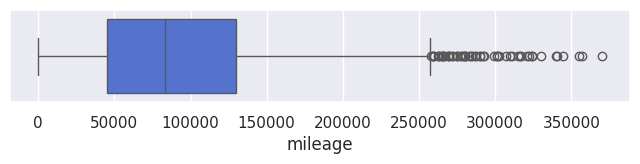

In [19]:
# Create a boxplot of the variable mileage
plt.figure(figsize = (8,1.2))       #definiert die Größe der Abbildung, wobei die Breite 8 und die Höhe 1.2 Einheiten beträgt
plt.ticklabel_format(style='plain') #definiert das Format der Achsenbeschriftungen auf 'plain', um wissenschaftliche Notation zu vermeiden
sns.boxplot(x=df['mileage'], color="royalblue")   #erstellt ein

### Histogram  (matplotlib)

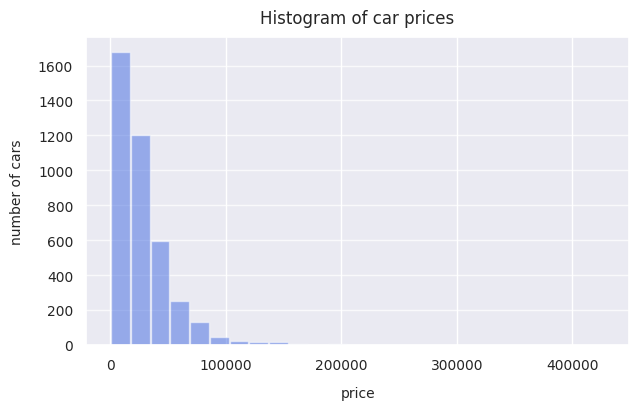

In [20]:
# Plot Histogram of the variable price
fig = plt.figure( figsize = (7,4))          #definiert die Größe der Abbildung, wobei die Breite 7 und die Höhe 4 Einheiten beträgt
plt.xticks(fontsize=14, rotation = 0)       #definiert die Schriftgröße der x-Achsenbeschriftungen auf 14 ohne Rotation
plt.yticks(fontsize = 14, rotation = 0)     #definiert die Schriftgröße der y-Achsenbeschriftungen auf 14 ohne Rotation

n, bins, patches = plt.hist(x=df['price'],
                            bins =25,
                            color = "royalblue",
                            alpha = 0.5,
                            rwidth = 0.95)

plt.grid(True)
plt.ticklabel_format(style='plain')   #definiert das Format der Achsenbeschriftungen auf 'plain', um wissenschaftliche Notation zu vermeiden
plt.grid(axis='y', alpha=0.75)

# Set labels
plt.xlabel('price', fontsize = 10, labelpad = 10)    #definiert die x-Achsenbeschriftung mit dem Text 'price', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
plt.ylabel('number of cars', fontsize = 10, labelpad = 10)   #definiert die y-Achsenbeschriftung mit dem Text 'number of cars', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
plt.title('Histogram of car prices', fontsize = 12, pad = 10)   #definiert den Titel der Abbildung mit dem Text 'Histogram of car prices' und einer Schriftgröße von 12, pad legt den Abstand des Titels zum oberen Rand der Abbildung fest

# Set fontsize of tick labels
plt.xticks(fontsize=10)        #definiert die Schriftgröße der x-Achsenbeschriftungen auf 10
plt.yticks(fontsize=10)        #definiert die Schriftgröße der y-Achsenbeschriftungen auf 10

# Show plot
plt.show()

### Density plot  (seaborn)

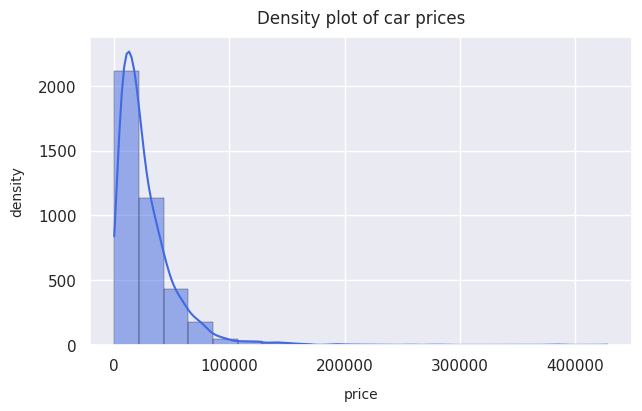

In [21]:
# Create a density plot of the variable price
plt.figure(figsize = (7, 4))
sns.histplot(df['price'],
             bins = 20,
             color = "royalblue",
             alpha = 0.5,
             kde = True,                    #fügt eine Kernel-Dichte-Schätzung (KDE) zur Histogramm-Darstellung hinzu, wenn True ist, dann wird die Dichtekurve über das Histogramm gelegt (True muss groß geschrieben werden)
             edgecolor = "black",           #  definiert die Farbe der Kanten der Balken im Histogramm auf schwarz
             linewidth = 0.2)               

# Set title and labels
plt.title('Density plot of car prices', fontsize=12, pad=10)   #definiert den Titel der Abbildung mit dem Text 'Density plot of car prices' und einer Schriftgröße von 12, pad legt den Abstand des Titels zum oberen Rand der Abbildung fest
plt.xlabel('price', fontsize=10, labelpad=10)      #definiert die x-Achsenbeschriftung mit dem Text 'price', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
plt.ylabel('density', fontsize=10, labelpad=10)    #definiert die y-Achsenbeschriftung mit dem Text 'density', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
plt.grid(True)

# Show plot
plt.show()

### Quantile-Quantile (QQ-) plot

      mileage       var
1140        1 -1.521350
832         1 -1.521350
3418       10 -1.521202
3618       10 -1.521202
2695       11 -1.521186
...       ...       ...
2597   340890  4.058032
3073   344500  4.117117
2723   355000  4.288972
1288   356673  4.316355
988    370000  4.534480

[3971 rows x 2 columns]


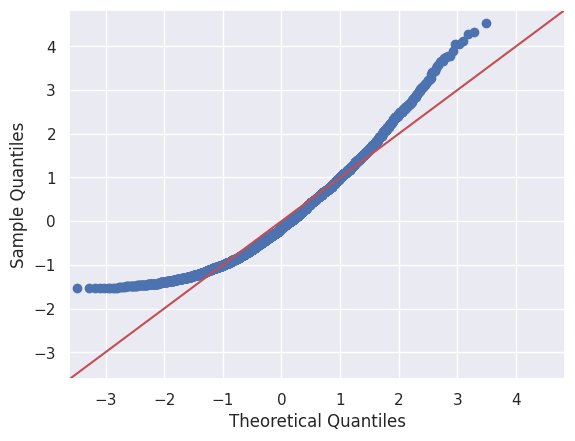

In [22]:
# Create qqplot of the variable mileage
x = 'mileage'
df_qq = df                      #definiert die DataFrame df_qq als Kopie der DataFrame df
df_qq['var'] = (df[x]-df[x].mean()) / df[x].std()       #diese Codezeile standardisiert die Variable 'mileage', indem der Mittelwert subtrahiert und durch die Standardabweichung geteilt wird

print(df_qq.sort_values('var')[['mileage', 'var']])     #dieser Code sortiert die DataFrame df_qq nach der standardisierten Variable 'var' und zeigt die Spalten 'mileage' und 'var' an
    
# Plot
sm.qqplot(df_qq['var'], line ='45')   #erstellt ein QQ-Plot der standardisierten Variable 'var' mit einer Referenzlinie bei 45 Grad
plt.show()


#der Quantile-Quantile-Plot (QQ-Plot) ist ein grafisches Werkzeug, um zu beurteilen, ob eine Stichprobe aus einer bestimmten Verteilung stammt.
#wenn die Punkte im QQ-Plot nahe an der Referenzlinie liegen, deutet dies darauf hin, dass die Stichprobe aus der angenommenen Verteilung stammt.

### Barchart  (matplotlib)

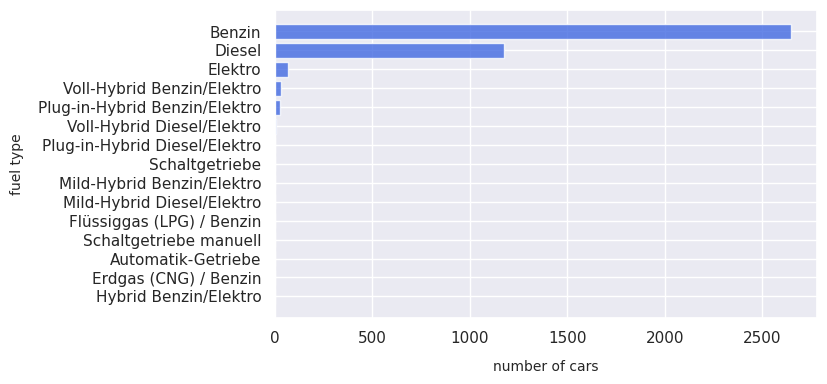

In [23]:
# Group data by fuel_type (only the topmost 15 values are shown)
df_bar = df['fuel_type'].value_counts().nlargest(15).sort_values(ascending = True)   #dieser Code erstellt eine DataFrame df_bar, die die 15 häufigsten Werte der Variablen 'fuel_type' enthält

# Values for barchart
napart = list(df_bar.values)        #dieser Code erstellt eine Liste napart, die die Werte der DataFrame df_bar enthält (napart steht für number of appearances)
index = list(df_bar.index.values)   #dieser Code erstellt eine Liste index, die die Indizes der DataFrame df_bar enthält
y_pos = np.arange(len(index))       #dieser Code erstellt ein Array y_pos, das die Positionen der Balken im Balkendiagramm definiert

# Figure
fig, ax = plt.subplots(figsize = (7,4))
ax.barh(y_pos, napart, align='center', color='royalblue', alpha = 0.8)    #dieser Code erstellt ein horizontales Balkendiagramm mit den Positionen y_pos und den Werten napart, wobei die Balken zentriert, in der Farbe 'royalblue' und mit einer Transparenz von 0.8 dargestellt werden
ax.set_yticks (y_pos, index)                                              #definiert die y-Achsenbeschriftungen mit den Positionen y_pos und den entsprechenden Kategorien aus der Liste index
ax.set_xlabel('number of cars', fontsize=10, labelpad=10)   #definiert die x-Achsenbeschriftung mit dem Text 'number of cars', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
ax.set_ylabel('fuel type', fontsize=10, labelpad=10)   #definiert die y-Achsenbeschriftung mit dem Text 'fuel type', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand

# Show graph
plt.show()

### Piechart (matplotlib)

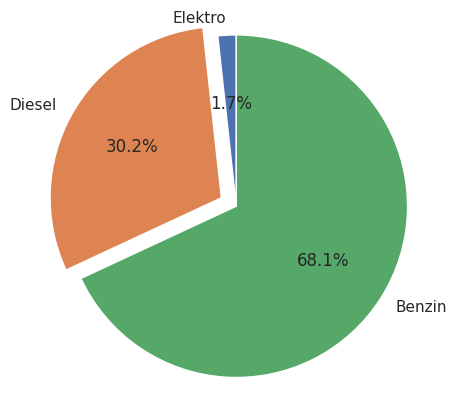

In [30]:
# Subset of cars with fuel type (only Diesel, Benzin and Elektro)
df_fuel =df[df['fuel_type'].isin(['Diesel', 'Benzin', 'Elektro'])]   #dieser Code erstellt eine DataFrame df_fuel, die nur die Autos mit den Kraftstoffarten Diesel, Benzin und Elektro enthält

# Group data by  (only the 8 most frequently occurencies)
df_bar = df_fuel.fuel_type.value_counts().nlargest(8).sort_values(ascending = True)   #dieser Code erstellt eine DataFrame df_bar, die die 8 häufigsten Werte der Variablen 'fuel_type' aus der DataFrame df_fuel enthält

# Simple bar chart
sizes = list(df_bar.values)        #dieser Code erstellt eine Liste sizes, die die Werte der DataFrame df_bar enthält
labels = list(df_bar.index.values)   #dieser Code erstellt eine Liste index, die die Indizes der DataFrame df_bar enthält
explode = (0, 0.1, 0)  


fig1, ax1 = plt.subplots(figsize = (5,5))
ax1.pie(sizes,
        labels = labels,
        explode = explode,
        autopct = '%1.1f%%',                #deifiert das Format der Prozentanzeige auf eine Nachkommastelle wobei autopct die Anzeige der Prozentwerte auf den Kuchenstücken steuert und %1.1f%% für eine Zahl mit einer Nachkommastelle und einem Prozentzeichen steht
        shadow = False,                      #fügt dem Tortendiagramm einen Schatteneffekt hinzu
        startangle = 90)                    #definiert den Startwinkel des Tortendiagramms auf 90 Grad
ax1.axis('equal')                           #stellt sicher, dass das Tortendiagramm kreisförmig dargestellt wird

# Show plot

plt.show()

## Multivariate graphical exploratory data analysis (EDA)

### Scatterplot (matplotlib)

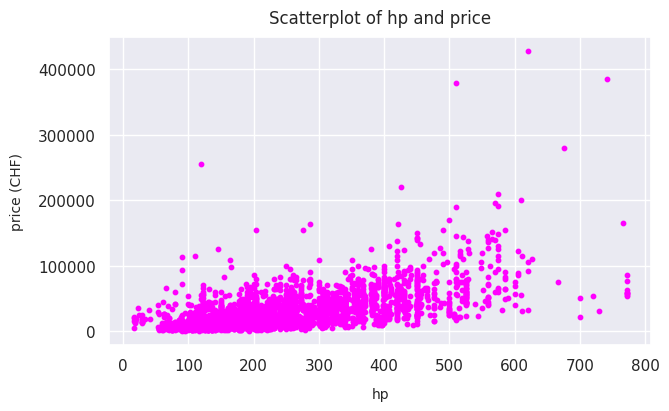

In [34]:
# Create a scatterplot of the variables hp and price
plt.figure(figsize=(7,4))
plt.scatter(df['hp'],
            df['price'],
            color="magenta",
            alpha=1.0,
            s=10)          #definiert die Größe der Punkte im Streudiagramm auf 10
plt.title('Scatterplot of hp and price', fontsize=12, pad=10)   #definiert den Titel der Abbildung mit dem Text 'Scatterplot of hp and price' und einer Schriftgröße von 12, pad legt den Abstand des Titels zum oberen Rand der Abbildung fest
plt.xlabel('hp', fontsize=10, labelpad=10)      #definiert die x-Achsenbeschriftung mit dem Text 'hp', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
plt.ylabel('price (CHF)', fontsize=10, labelpad=10)    #definiert die y-Achsenbeschriftung mit dem  Text 'price (CHF)', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand

plt.show()

### Scatterplot (matplotlib) with regression line

(3963, 15)
136.82386275955662
-4720.431165293197


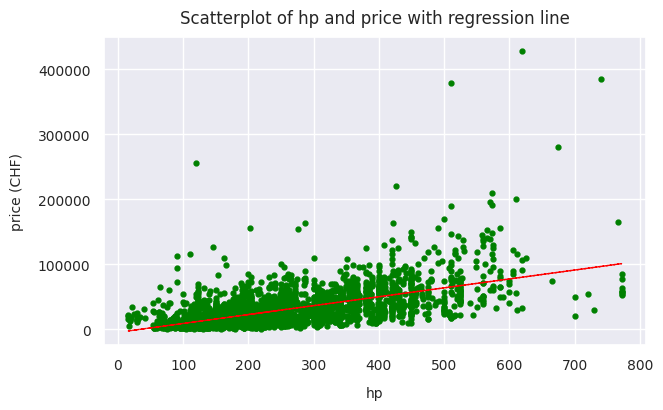

In [40]:
# Create a scatterplot of the variables hp and price
df_sub = df.loc[(df.price >= 1000)]         #dieser Code erstellt eine DataFrame df_sub, die nur die Autos mit einem Preis von mehr als oder gleich 1000 enthält     
print(df_sub.shape)                 #zeigt die Anzahl der Zeilen und Spalten der DataFrame df_sub an

# Add a regression line (b = slope, a=intercept) to the plot
plt.figure(figsize=(7,4))
plt.plot(df_sub.hp,                         #df_sub.hp sind die x-Werte
         df_sub.price,                      #df_sub.price sind die y-Werte
         'o',                               #' o ' definiert die Form der Punkte im Streudiagramm als Kreise
         markersize = 3.5,                  #definiert die Größe der Punkte im Streudiagramm auf 3.5
         color = "green")

#Regressionslinie
b, a = np.polyfit(df_sub.hp, df_sub.price, 1)   #berechnet die Koeffizienten b (Steigung) und a (y-Achsenabschnitt) der Regressionslinie durch lineare Anpassung der Datenpunkte, wobei np.polyfit eine Funktion ist, die eine lineare Regression durchführt
print(b)
print(a)

#Regressionslinie plotten
plt.plot(df_sub.hp, 
         b*df_sub.hp + a,
         linewidth = 1,
         linestyle = 'dashed',
         color = 'red')

# Titel und Achsenbeschriftungen
plt.title('Scatterplot of hp and price with regression line', fontsize=12, pad=10)   #definiert den Titel der Abbildung mit dem Text 'Scatterplot of hp and price with regression line' und einer Schriftgröße von 12, pad legt den Abstand des Titels zum oberen Rand der Abbildung fest
plt.xlabel('hp', fontsize=10, labelpad=10)      #definiert die x-Achsenbeschriftung mit dem Text 'hp', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand
plt.ylabel('price (CHF)', fontsize=10, labelpad=10)    #definiert die y-Achsenbeschriftung mit dem  Text 'price (CHF)', einer Schriftgröße von 10 und einem Abstand von 10 Einheiten zum Achsenrand

# Setzten von fontsize und rotation der tick labels
plt.xticks(fontsize=10)        #definiert die Schriftgröße der x-Achsenbeschriftungen auf 10
plt.yticks(fontsize=10)        #definiert die Schriftgröße der y-Achsenbeschriftungen auf 10

# Show plot
plt.show()


### Scatterplot-matrix (seaborn)

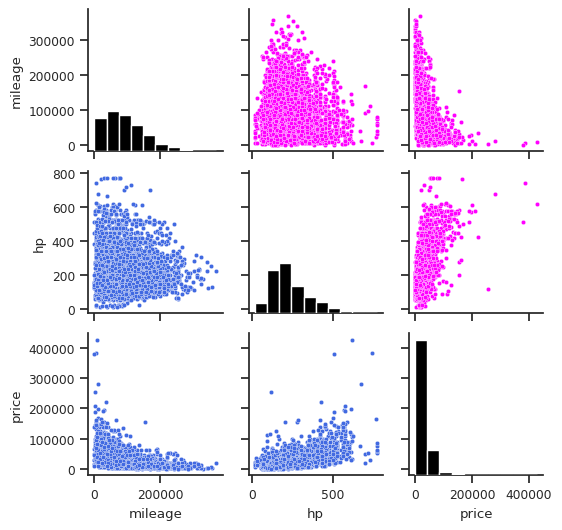

In [42]:
# Create a scatterplot of the variables mileage, price and hp
sns.set_theme(style = "ticks", font_scale = 0.8)                #sns.set_theme legt das allgemeine Erscheinungsbild der Seaborn-Grafiken fest, wobei style = "ticks" ein bestimmtes Design mit Tick-Markierungen auswählt und font_scale = 0.8 die Schriftgröße in den Grafiken auf 80% der Standardgröße skaliert

                                                                #"ticks" definiert das Design der Grafik mit Tick-Markierungen entlang der Achsen

g = sns.PairGrid(df[['mileage',
                     'hp',
                     'price']],                                 #die [] definieren die DataFrame mit den ausgewählten Variablen
                     height =1.8,                               #definiert die Höhe jeder Grafik in der PairGrid auf 1.8 Einheiten
                     aspect = 1)                  #definiert das Seitenverhältnis jeder Grafik in der PairGrid auf 1 (quadratisch) 

g.map_upper(sns.scatterplot, color="magenta", s=10)   #erstellt Streudiagramme in den oberen Dreieckspositionen der PairGrid mit Punkten in der Farbe 'magenta' und einer Größe von 10 wobei s die Größe der Punkte im Streudiagramm definiert
g.map_lower(sns.scatterplot, color = "royalblue", s=10)              #erstellt KDE-Diagramme in den unteren Dreieckspositionen der PairGrid mit einer Farbe 'royalblue' und einer Größe von 10 wobei s die Größe der Punkte im Streudiagramm definiert
g.map_diag(plt.hist, color = "black")

# Show plot
plt.show()

### Hexagonal binning plot  (matplotlib)

In [ ]:
# Subset of cars with price <= 100000 and hp <= 400


# Create a scatterplot of the variables hp and price


# Set axes labels


# Show plot

### Correlation heatmap (seaborn)

In [ ]:
# Create correlation matrix with variable price, mileage and hp


# Plot heatmap


### Bubble plot (seaborn)

In [ ]:
# Create a scatterplot of the variables mileage, price, hp, price_per_hp
# price on the y-axis
# hp on the x-axis
# price_per_hp determines bubble size
# mileage determines color



### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [ ]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')